# DiMMAD anomaly scoring on ZTF/RELAISS features

1. Loads a RELAISS feature table (with durations + sky coords)
2. Applies basic quality cuts (duration, Galactic latitude)
3. Cross-matches to ALeRCE explorer export to get class labels
4. Trains DiMMAD (distclassipy DistanceAnomaly) on *known* classes
5. Scores an unlabeled/unknown set and ranks anomalies




In [4]:
# --- Imports & settings ---
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

from astropy.coordinates import SkyCoord
import astropy.units as u

from distclassipy.anomaly import DistanceAnomaly

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)


In [9]:
# --- Paths ---
DATA_DIR = Path("data")          
OUT_DIR  = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RELAISS_CSV = DATA_DIR / "reference_20k_with_durations.csv"
ALERCE_EXPLORER_CSV = DATA_DIR / "btsztf.csv"
#ALERCE_EXPLORER_CSV = Path("experiments") / "explorer.csv"  

RELAISS_CSV, ALERCE_EXPLORER_CSV


(PosixPath('data/reference_20k_with_durations.csv'),
 PosixPath('data/btsztf.csv'))

## Load data

In [11]:
df = pd.read_csv(RELAISS_CSV, low_memory=False)
df.head()

,t0,g_peak_mag,g_peak_time,g_rise_time,g_decline_time,g_duration_above_half_flux,g_amplitude,g_skewness,g_beyond_2sigma,r_peak_mag,r_peak_time,r_rise_time,r_decline_time,r_duration_above_half_flux,r_amplitude,r_skewness,r_beyond_2sigma,mean_g-r,g-r_at_g_peak,mean_color_rate,g_n_peaks,g_dt_main_to_secondary_peak,g_dmag_secondary_peak,g_secondary_peak_prominence,g_secondary_peak_width,r_n_peaks,r_dt_main_to_secondary_peak,r_dmag_secondary_peak,r_secondary_peak_prominence,r_secondary_peak_width,g_max_rolling_variance,g_mean_rolling_variance,r_max_rolling_variance,r_mean_rolling_variance,g_rise_local_curvature,g_decline_local_curvature,r_rise_local_curvature,r_decline_local_curvature,features_valid,t0_err,g_peak_mag_err,g_peak_time_err,g_rise_time_err,g_decline_time_err,g_duration_above_half_flux_err,g_amplitude_err,g_skewness_err,g_beyond_2sigma_err,r_peak_mag_err,r_peak_time_err,r_rise_time_err,r_decline_time_err,r_duration_above_half_flux_err,r_amplitude_err,r_skewness_err,r_beyond_2sigma_err,mean_g-r_err,g-r_at_g_peak_err,mean_color_rate_err,g_n_peaks_err,g_dt_main_to_secondary_peak_err,g_dmag_secondary_peak_err,g_secondary_peak_prominence_err,g_secondary_peak_width_err,r_n_peaks_err,r_dt_main_to_secondary_peak_err,r_dmag_secondary_peak_err,r_secondary_peak_prominence_err,r_secondary_peak_width_err,g_max_rolling_variance_err,g_mean_rolling_variance_err,r_max_rolling_variance_err,r_mean_rolling_variance_err,g_rise_local_curvature_err,g_decline_local_curvature_err,r_rise_local_curvature_err,r_decline_local_curvature_err,features_valid_err,ZTFID,ra,dec,Unnamed: 0,idx,best_cat,best_cat_release,query_time,smallcone_posterior,missedcat_posterior,extra_cat_cols,host_objID,host_name,host_total_posterior,host_ra,host_dec,host_redshift_mean,host_redshift_std,host_absmag_mean,host_absmag_std,host_absmag_info,host_offset_mean,...,rExtNSigma,iKronRad,yExtNSigma,ymomentYY,ny,zstackDetectID,gEpoch,iFPSFFlux,nStackDetections,KronMag,ypsfLikelihood,iinfoFlag,zFPSFFlux,zpsfCore,momentXY,ypsfMinorFWHM,zPSFMag,yraErr,iFApFlux,zPSFMagErr,iPSFFluxErr,rinfoFlag,ipsfMinorFWHM,inFrames,gpsfMinorFWHM,gmomentXX,iKronFluxErr,ng,rpsfCore,raStack,zFKronFlux,uniquePspsSTid,objAltName1,iPSFMag,zApRadius,decStackErr,gmomentR1,yApFluxErr,zinfoFlag,rmomentR1,gzp,iKronFlux,randomID,surveyID,cx,imomentRH,ydec,gyPosErr,rra,rKronRad,zpsfMinorFWHM,yApFillFac,yKronMag,uniquePspsOBid,rpsfTheta,zApMagErr,iippDetectID,iinfoFlag2,ystackDetectID,batchID,rFmeanflxR5,zFmeanflxR7,iEpoch,zxPosErr,rpsfLikelihood,yPSFFlux,yEpoch,rKronMag,gdecErr,zmomentXX,yinfoFlag,zpsfChiSq,zexpTime,zKronMagErr,rKronFluxErr,gKronFluxErr,gKronFlux,rFApFlux,gPSFFlux,gKronMag,iraErr,gstackImageID,yFmeanflxR6,graErr,ipsfQf,iFmeanflxR5,zExtNSigma,ypsfCore,zFmeanflxR6,iFmeanflxR6,mjd_extracted,tns_redshift,latest_magnitude,oldest_alert,newest_alert,peak_phase,antares_oldest_alert,antares_newest_alert,antares_duration,duration_days
0,59850.515694,18.058201,19.991794,6.032847,12.011400,18.044248,0.521299,0.225308,0.0,17.598600,0.000000,NaN,33.467286,31.981111,1.021000,-0.492451,0.083333,0.109230,0.027208,0.016575,1,NaN,NaN,NaN,NaN,2,12.119703,0.211326,0.249921,20.899493,0.000295,0.000144,0.071492,0.001672,-0.007540,-0.002478,NaN,-0.005436,False,0.0,0.058249,0.903369,0.903369,0.903369,0.000000,0.074867,0.576231,6.117006e-02,0.170234,0.000000,NaN,16.194011,4.325329,0.154256,0.477562,0.045843,0.051900,0.119613,0.008798,0.615587,4.181948,0.153224,0.045004,13.055632,0.638666,3.519174,0.126541,0.123748,7.833686,0.000581,0.000123,0.054051,0.000855,0.021606,0.012067,NaN,0.006085,0.0,ZTF17aabtvsy,158.883762,37.649729,5.0,19226.0,panstarrs,dr2,6.246375,1.341795e-15,1.341795e-15,"{'iinfoFlag3': 196608.0, 'zpsfQfPerfect': 0.99...",1.531816e+17,NaN,0.987186,158.883575,37.649555,0.077098,0.019274,-22.734511,0.749100,r,0.829189,...,13.785300,17.996799,23.644100,0.228099,13.0,2.523244e+18,55923.256190,0.000530,5.0,14.982000,0.000000,262160391.0,0.000617,0.425564,-0.002408,0.943950,16.888700,0.001657,0.001063,0.001878

## Basic cuts
- remove long-duration objects (duration_days > 200)
- avoid Galactic plane (|b| < 15°)

In [12]:
DURATION_MAX_DAYS = 200
LAT_CUT_DEG = 15.0

coords = SkyCoord(ra=df["ra"].values * u.deg, dec=df["dec"].values * u.deg, frame="icrs")
b = coords.galactic.b.deg

mask = (df["duration_days"] <= DURATION_MAX_DAYS) & (np.abs(b) >= LAT_CUT_DEG)
df_cut = df.loc[mask].copy()

print(f"Kept {len(df_cut):,} / {len(df):,} rows")
df_cut[["ra","dec","duration_days"]].describe()


Kept 17,254 / 25,515 rows


,ra,dec,duration_days
count,17254.000000,17254.000000,17254.000000
mean,188.015840,24.437389,34.787190
std,100.977707,26.450765,28.723007
min,0.043749,-28.523936,0.000000
25%,119.742843,4.123706,15.955255
50%,198.005768,23.648384,26.980735
75%,261.960899,43.098598,42.882037
max,359.998678,87.537761,199.721447


## Cross-match to labeled catalog
Original notebook tried to match by `ZTFID` and now switched to coordinate matching.

Instead:
- converts ALeRCE RA/Dec strings into degrees
- matches each `df_cut` row to nearest ALeRCE object
- keeps matches within 1 arcsec


In [15]:
zdf = pd.read_csv(ALERCE_EXPLORER_CSV, low_memory=False)

df_cut["ZTFID"].describe()

df_matched = df_cut.merge(
    zdf,
    on="ZTFID",
    how="inner"   
)

len(set(df_cut["ZTFID"]) & set(zdf["ZTFID"]))

#df_cut["ZTFID"].isna().sum()
#df_cut["ZTFID"].duplicated().sum()

tmp = df_cut.merge(
    zdf,
    on="ZTFID",
    how="left",
    indicator=True
)

df_matched   = tmp[tmp["_merge"] == "both"].drop(columns=["_merge"])
df_unmatched = tmp[tmp["_merge"] == "left_only"].drop(columns=["_merge"])


In [17]:
zdf = pd.read_csv(ALERCE_EXPLORER_CSV, low_memory=False)

# ALeRCE explorer export often stores RA as hourangle string and Dec as deg string
alerce_coords = SkyCoord(
    ra=zdf["RA"].astype(str),
    dec=zdf["Dec"].astype(str),
    unit=(u.hourangle, u.deg)
)
zdf = zdf.copy()
zdf["ra_deg"] = alerce_coords.ra.deg
zdf["dec_deg"] = alerce_coords.dec.deg

ref_coords = SkyCoord(ra=df_cut["ra"].values * u.deg, dec=df_cut["dec"].values * u.deg)

idx, sep2d, _ = ref_coords.match_to_catalog_sky(alerce_coords)
mask_match = sep2d < (1.0 * u.arcsec)

df_cut = df_cut.copy()
df_cut["alerce_idx"] = idx
df_cut["matched"] = mask_match

df_matched = df_cut.loc[mask_match].merge(
    zdf[["ra_deg","dec_deg","ZTFID","type","IAUID"]],
    left_on="alerce_idx",
    right_index=True,
    how="left"
)

df_unmatched = df_cut.loc[~mask_match].copy()

print(f"Matched: {len(df_matched):,}")
print(f"Unmatched: {len(df_unmatched):,}")

# After df_matched is created:
print([c for c in df_matched.columns if "ZTF" in c.upper()])

# Common fix:
if "ZTFID_x" in df_matched.columns:
    df_matched = df_matched.rename(columns={"ZTFID_x": "ZTFID"})
elif "ZTFID_y" in df_matched.columns:
    df_matched = df_matched.rename(columns={"ZTFID_y": "ZTFID"})

df_matched[["ZTFID","type","IAUID","ra","dec"]].head()


Matched: 3,835
Unmatched: 13,419
['ZTFID_x', 'ZTFID_y']


,ZTFID,type,IAUID,ra,dec
0,ZTF17aabtvsy,SN Ia,SN2022yei,158.883762,37.649729
1,ZTF17aabvong,SN Ia,SN2024xxq,31.282032,11.248651
23,ZTF18aacnlxz,SN II,SN2020aavr,134.954664,38.109070
27,ZTF18aaczmob,-,-,105.519506,49.059275
28,ZTF18aadaexi,-,AT2021dpr,125.241560,36.312320


## Map labels to classifications
Training set of present classes and an 'unknown/unlabeled' set to score.


In [19]:

TYPE_MAP = {
    # Superluminous
    "SLSN-I": "SLSN",
    "SLSN-II": "SLSN",

    # Type II
    "SN II": "II",
    "SN IIP": "II",

    # Type IIb / IIn
    "SN IIb": "IIb",
    "SN IIn": "IIn",

    # Thermonuclear (Ia family)
    "SN Ia": "Ia",
    "SN Ia-91T": "Ia",
    "SN Ia-91bg": "Ia",
    "SN Ia-SC": "Ia",
    "SN Iax": "Ia",

    # Stripped-envelope
    "SN Ib": "Ibc",
    "SN Ib/c": "Ibc",
    "SN Ic": "Ibc",
    "SN Ic-BL": "Ibc",

    # TDE
    "TDE": "TDE",
    "TDE-He": "TDE",
}

def map_type(t):
    if pd.isna(t):
        return np.nan
    t = str(t).strip()
    return TYPE_MAP.get(t, "UNKNOWN")

In [21]:
df_matched["type_group"] = df_matched["type"].apply(map_type)
print(df_matched["type_group"].value_counts(dropna=False))

known_groups = ["SLSN", "II", "IIb", "IIn", "Ia", "Ibc", "TDE"]

df_train = df_matched[df_matched["type_group"].isin(known_groups)].copy()

df_anom = pd.concat(
    [df_unmatched, df_matched[df_matched["type_group"] == "UNKNOWN"]],
    ignore_index=True
)

print(f"Train rows: {len(df_train):,}")
print(f"To-score rows: {len(df_anom):,}")

type_group
Ia         2116
UNKNOWN    1143
II          320
Ibc         125
IIn          49
IIb          41
SLSN         24
TDE          17
Name: count, dtype: int64
Train rows: 2,692
To-score rows: 14,562


In [23]:
known_groups = ["SLSN", "IIP", "IIb", "IIn", "Ia", "Ibc", "TDE"]

df_train = df_matched[df_matched["type_group"].isin(known_groups)].copy()
df_anom  = pd.concat(
    [df_unmatched, df_matched[df_matched["type_group"] == "UNKNOWN"]],
    ignore_index=True
)

print(f"Train rows: {len(df_train):,}")
print(f"To-score rows: {len(df_anom):,}")


Train rows: 2,372
To-score rows: 14,562


## Feature selection + preprocessing
Key cleanup from the original notebook:
- Numeric columns are used (avoid `ZTFID` strings)
- handle ±inf → NaN
- KNN impute, then standardize


In [27]:
# Choose feature columns: all numeric columns except obvious ID/coord/label fields.
DROP_COLS = {
    "ZTFID", "IAUID", "type", "type_group",
    "alerce_idx", "matched"
}
# Also drop raw coords
DROP_COLS |= {"ra", "dec", "ra_deg", "dec_deg"}

numeric_cols = [c for c in df_train.columns if pd.api.types.is_numeric_dtype(df_train[c])]
feature_cols = [c for c in numeric_cols if c not in DROP_COLS]

print(f"Using {len(feature_cols)} numeric features.")
feature_cols[:20]


Using 453 numeric features.


['t0',
 'g_peak_mag',
 'g_peak_time',
 'g_rise_time',
 'g_decline_time',
 'g_duration_above_half_flux',
 'g_amplitude',
 'g_skewness',
 'g_beyond_2sigma',
 'r_peak_mag',
 'r_peak_time',
 'r_rise_time',
 'r_decline_time',
 'r_duration_above_half_flux',
 'r_amplitude',
 'r_skewness',
 'r_beyond_2sigma',
 'mean_g-r',
 'g-r_at_g_peak',
 'mean_color_rate']

In [29]:
def preprocess(train_df: pd.DataFrame, score_df: pd.DataFrame, feature_cols, n_neighbors=5):
    X_train_raw = train_df[feature_cols].replace([np.inf, -np.inf], np.nan)
    X_score_raw = score_df[feature_cols].replace([np.inf, -np.inf], np.nan)

    imputer = KNNImputer(n_neighbors=n_neighbors, weights="distance")
    X_train_imp = imputer.fit_transform(X_train_raw)
    X_score_imp = imputer.transform(X_score_raw)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_imp)
    X_score = scaler.transform(X_score_imp)

    return X_train, X_score, imputer, scaler

X_train, X_score, imputer, scaler = preprocess(df_train, df_anom, feature_cols)
y_train = df_train["type_group"].values

X_train.shape, X_score.shape


((2696, 438), (14557, 438))

## DiMMAD scoring (median-median)
`cluster_agg` controls how each class cluster is aggregated; `metric_agg` controls aggregation across distance metrics.


In [32]:
dimmad_medmed = DistanceAnomaly(
    cluster_agg="median",
    metric_agg="median",
    normalize_scores=True
)

dimmad_medmed.fit(X_train, y_train)
scores_medmed = dimmad_medmed.score_samples(X_score)

df_anom = df_anom.copy()
df_anom["dimmad_medmed"] = scores_medmed

df_anom[["dimmad_medmed"]].describe()


,dimmad_medmed
count,1.455700e+04
mean,-1.194317e-03
std,2.572055e-02
min,-8.317671e-01
25%,-1.297573e-13
50%,-5.353190e-14
75%,-3.422954e-14
max,-7.235006e-17


In [42]:
# Rank top anomalies
df_ranked_med = df_anom.sort_values("dimmad_medmed", ascending=True).copy()
df_ranked_med[["ZTFID","dimmad_medmed"]].head(20)


,ZTFID,dimmad_medmed
13575,ZTF24abrirtr,-0.831767
2707,ZTF21aarifeh,-0.782056
26,ZTF18aaeopbs,-0.724015
130,ZTF18aawsmrt,-0.713799
13259,ZTF24abkgvhk,-0.713446
13367,ZTF24abmjjac,-0.705353
11570,ZTF24aaemydm,-0.667641
2308,ZTF21aalgtgo,-0.659539
10578,ZTF23abblpvm,-0.657324
10455,ZTF23aazyjxq,-0.622791


In [44]:
# Save
rank_path = OUT_DIR / "dimmad_ranked_medmed.csv"
df_ranked_med.to_csv(rank_path, index=False)
rank_path


PosixPath('outputs/dimmad_ranked_medmed.csv')

## Compare aggregation choices (min-median)

In [59]:
dimmad_minmed = DistanceAnomaly(
    cluster_agg="min",
    metric_agg="median",
    normalize_scores=True
)

dimmad_minmed.fit(X_train, y_train)
scores_minmed = dimmad_minmed.score_samples(X_score)

df_anom["dimmad_minmed"] = scores_minmed
df_anom[["dimmad_medmed","dimmad_minmed"]].head()


,dimmad_medmed,dimmad_minmed
0,-4.187967e-12,-0.001503
1,-2.158663e-14,-0.001324
2,-1.202602e-13,-0.001224
3,-6.721686e-14,-0.001417
4,-5.004757e-14,-0.000662


In [60]:
df_ranked_min = df_anom.sort_values("dimmad_minmed", ascending=True).copy()
df_ranked_min[["ZTFID","dimmad_minmed"]].head(20)


,ZTFID,dimmad_minmed
11570,ZTF24aaemydm,-0.975135
6342,ZTF22aakdbia,-0.935496
9370,ZTF23aaixyan,-0.692445
6263,ZTF22aajfxrx,-0.272871
9139,ZTF23aaflnxp,-0.263776
6760,ZTF22aaoonxc,-0.230819
6256,ZTF22aajbqel,-0.210001
6293,ZTF22aajkifc,-0.203057
6255,ZTF22aajbpzc,-0.194996
6426,ZTF22aakmpud,-0.148340


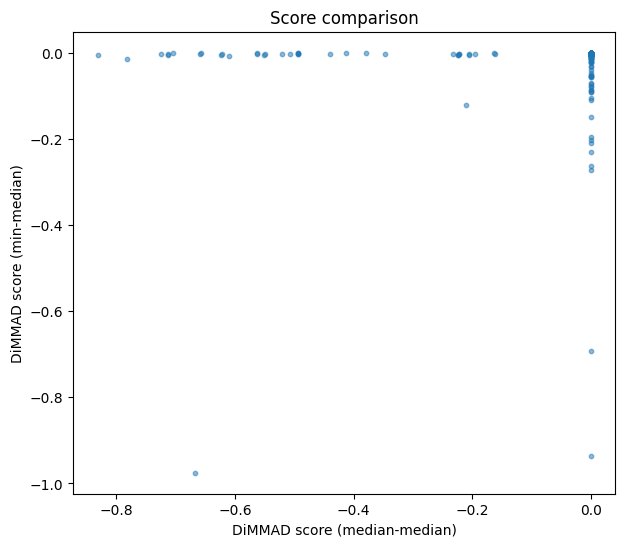

In [69]:
plt.figure(figsize=(7,6))
plt.scatter(df_anom["dimmad_medmed"], df_anom["dimmad_minmed"], s=10, alpha=0.5)
plt.xlabel("DiMMAD score (median-median)")
plt.ylabel("DiMMAD score (min-median)")
plt.title("Score comparison")
plt.show()

## Make sure this is correct....


## Compare anomalies in both:

In [73]:
# DiMMAD scores are negative; more negative = more anomalous

In [71]:
print("med–med min/max:", df_anom["dimmad_medmed"].min(), df_anom["dimmad_medmed"].max())
print("min–med min/max:", df_anom["dimmad_minmed"].min(), df_anom["dimmad_minmed"].max())


med–med min/max: -0.8317670914291997 -7.235005541225614e-17
min–med min/max: -0.9751346669071097 -5.309226567735231e-15


In [75]:
# Objects that are extreme (use 5th percentile NOT 95)
p5_med = np.percentile(df_anom["dimmad_medmed"], 5)
p5_min = np.percentile(df_anom["dimmad_minmed"], 5)

df_both = df_anom[
    (df_anom["dimmad_medmed"] <= p5_med) &
    (df_anom["dimmad_minmed"] <= p5_min)
].copy()
print(f"Robust anomalies (>=95th percentile in both): {len(df_both):,}")

#p95_med = np.percentile(df_anom["dimmad_medmed"], 95)
#p95_min = np.percentile(df_anom["dimmad_minmed"], 95)

#df_both = df_anom[(df_anom["dimmad_medmed"] >= p95_med) & (df_anom["dimmad_minmed"] >= p95_min)].copy()


df_both.sort_values("dimmad_medmed", ascending=True)[["ZTFID","dimmad_medmed","dimmad_minmed"]].head(20)


Robust anomalies (>=95th percentile in both): 233


,ZTFID,dimmad_medmed,dimmad_minmed
13575,ZTF24abrirtr,-8.317671e-01,-0.006347
2707,ZTF21aarifeh,-7.820558e-01,-0.015045
130,ZTF18aawsmrt,-7.137989e-01,-0.005090
13259,ZTF24abkgvhk,-7.134457e-01,-0.003777
11570,ZTF24aaemydm,-6.676408e-01,-0.975135
10455,ZTF23aazyjxq,-6.227912e-01,-0.006207
8653,ZTF22acahury,-6.096589e-01,-0.007623
8556,ZTF22abyistt,-5.632294e-01,-0.003233
3195,ZTF21aaxszfg,-5.510921e-01,-0.004618
1446,ZTF20acwombm,-5.500423e-01,-0.002752


In [78]:
out_cols = [
    "ZTFID",
    "dimmad_medmed",
    "dimmad_minmed",
]

df_anom[out_cols].to_csv(
    "outputs/dimmad_anomaly_scores.csv",
    index=False
)

# Now can use df_dimmad = pd.read_csv("outputs/dimmad_anomaly_scores.csv")


In [83]:
df_save = df_anom.copy()

df_save["rank_medmed"] = df_save["dimmad_medmed"].rank(method="min")
df_save["rank_minmed"] = df_save["dimmad_minmed"].rank(method="min")

p5_med = np.percentile(df_save["dimmad_medmed"], 5)
p5_min = np.percentile(df_save["dimmad_minmed"], 5)

df_save["robust_dimmad"] = (
    (df_save["dimmad_medmed"] <= p5_med) &
    (df_save["dimmad_minmed"] <= p5_min)
)

df_save[
    ["ZTFID", "dimmad_medmed", "dimmad_minmed",
     "rank_medmed", "rank_minmed", "robust_dimmad"]
].to_csv(
    "outputs/ranked_dimmadscores.csv",
    index=False
)


## Distribution checks

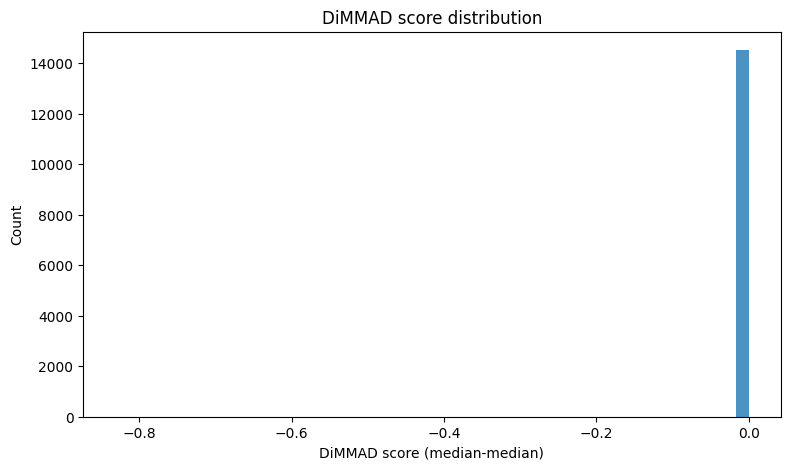

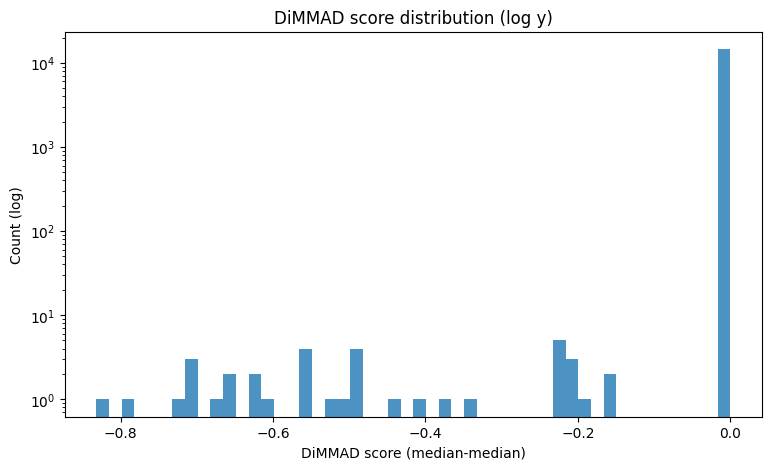

In [80]:
plt.figure(figsize=(9,5))
plt.hist(df_anom["dimmad_medmed"], bins=50, alpha=0.8)
plt.xlabel("DiMMAD score (median-median)")
plt.ylabel("Count")
plt.title("DiMMAD score distribution")
plt.show()

plt.figure(figsize=(9,5))
plt.hist(df_anom["dimmad_medmed"], bins=50, alpha=0.8)
plt.yscale("log")
plt.xlabel("DiMMAD score (median-median)")
plt.ylabel("Count (log)")
plt.title("DiMMAD score distribution (log y)")
plt.show()


## Fetch lightcurves / cutouts from ALeRCE

